# Grocery Data Pattern Mining Analysis

This notebook explores the grocery transaction dataset and implements pattern mining techniques to discover frequent itemsets and association rules. We'll explore the data first, then implement the pattern mining algorithm.

## 1. Data Exploration and Preprocessing

load and explore the dataset to understand its structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import combinations
import math

# Set plot style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

In [2]:
# Load the training data
train_data = pd.read_csv('Groceries data train.csv')

# Check basic info
print(f"Dataset shape: {train_data.shape}")
train_data.head()


Dataset shape: (19382, 7)


,User_id,Date,itemDescription,year,month,day,day_of_week
0,2351,1/01/2014,cleaner,2014,1,1,2
1,2226,1/01/2014,sausage,2014,1,1,2
2,1922,1/01/2014,tropical fruit,2014,1,1,2
3,2943,1/01/2014,whole milk,2014,1,1,2
4,1249,1/01/2014,citrus fruit,2014,1,1,2


examine the data types and check for missing values:

In [3]:
# Data types and missing values
train_data.info()
print("\nMissing values:")
print(train_data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User_id          19382 non-null  int64 
 1   Date             19382 non-null  object
 2   itemDescription  19382 non-null  object
 3   year             19382 non-null  int64 
 4   month            19382 non-null  int64 
 5   day              19382 non-null  int64 
 6   day_of_week      19382 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.0+ MB

Missing values:
User_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64


convert the date to proper datetime format for analysis:

In [4]:
# Convert date to datetime
train_data['Date'] = pd.to_datetime(train_data['Date'], format='%d/%m/%Y')

# Add some temporal features
train_data['week'] = train_data['Date'].dt.isocalendar().week
train_data['month_name'] = train_data['Date'].dt.month_name()

# Verify date conversion
print("Date range:", train_data['Date'].min(), "to", train_data['Date'].max())
train_data.head()

Date range: 2014-01-01 00:00:00 to 2015-01-20 00:00:00


,User_id,Date,itemDescription,year,month,day,day_of_week,week,month_name
0,2351,2014-01-01,cleaner,2014,1,1,2,1,January
1,2226,2014-01-01,sausage,2014,1,1,2,1,January
2,1922,2014-01-01,tropical fruit,2014,1,1,2,1,January
3,2943,2014-01-01,whole milk,2014,1,1,2,1,January
4,1249,2014-01-01,citrus fruit,2014,1,1,2,1,January


### 1.1 Exploratory Data Analysis  
analyze the basic characteristics of our dataset:

In [5]:
# Number of unique users and items
print(f"Number of unique users: {train_data['User_id'].nunique()}")
print(f"Number of unique items: {train_data['itemDescription'].nunique()}")

# Count transactions (unique user-date combinations)
transactions = train_data.groupby(['User_id', 'Date'])['itemDescription'].count()
print(f"Number of transactions: {len(transactions)}")
print(f"Average items per transaction: {transactions.mean():.2f}")

Number of unique users: 3493
Number of unique items: 167
Number of transactions: 8361
Average items per transaction: 2.32


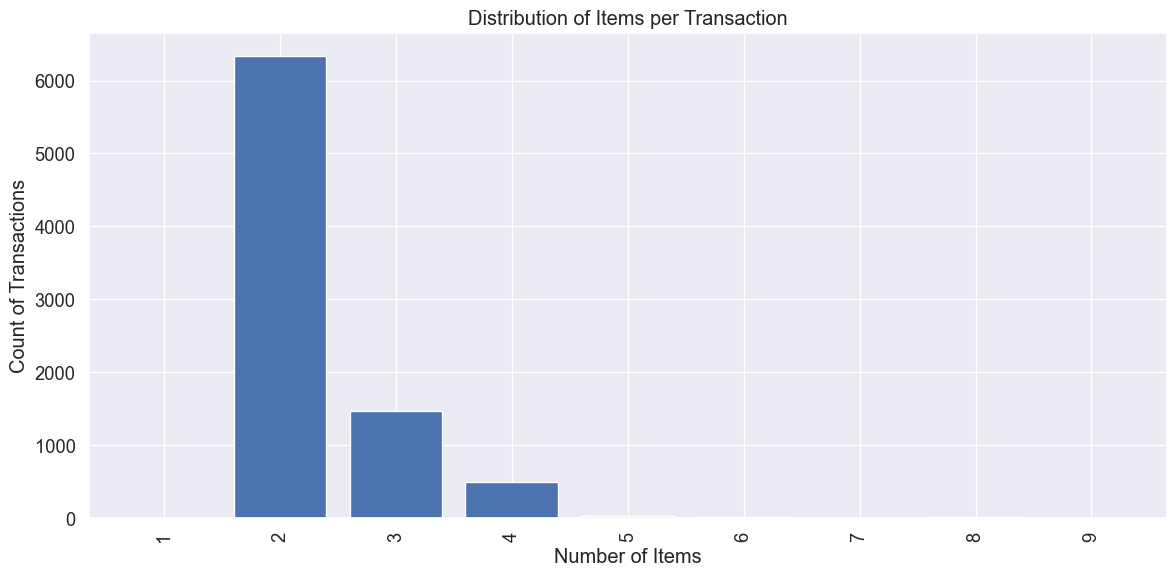

In [6]:
# Distribution of transaction sizes
plt.figure(figsize=(12, 6))
transactions.value_counts().sort_index().plot(kind='bar', width=0.8)
plt.title('Distribution of Items per Transaction')
plt.xlabel('Number of Items')
plt.ylabel('Count of Transactions')
plt.tight_layout()
plt.show()

the most popular items:

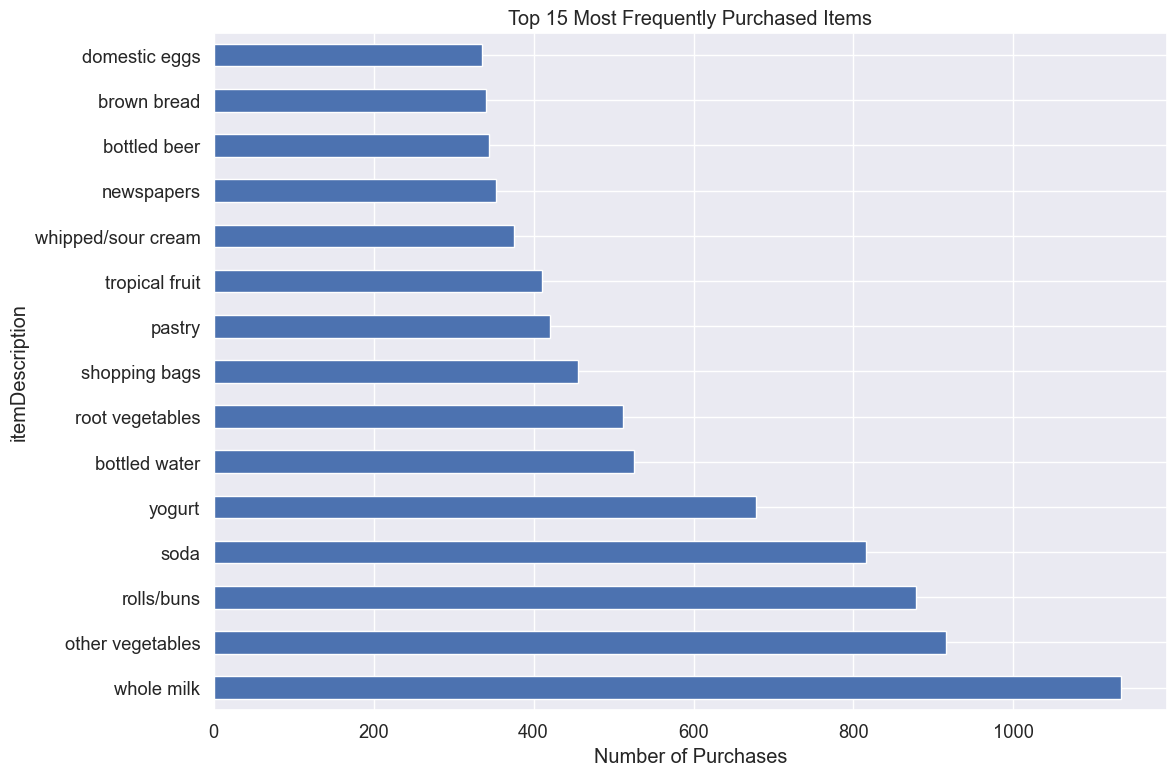

In [7]:
# Most frequent items
item_counts = train_data['itemDescription'].value_counts()
top_items = item_counts.head(15)

plt.figure(figsize=(12, 8))
top_items.plot(kind='barh')
plt.title('Top 15 Most Frequently Purchased Items')
plt.xlabel('Number of Purchases')
plt.tight_layout()
plt.show()

In [8]:
# Show the percentage of total purchases
print("Top items as percentage of all purchases:")
total = len(train_data)
for item, count in top_items.items():
    print(f"{item}: {count/total*100:.2f}%")

Top items as percentage of all purchases:
whole milk: 5.86%
other vegetables: 4.73%
rolls/buns: 4.53%
soda: 4.21%
yogurt: 3.50%
bottled water: 2.71%
root vegetables: 2.64%
shopping bags: 2.35%
pastry: 2.17%
tropical fruit: 2.12%
whipped/sour cream: 1.94%
newspapers: 1.82%
bottled beer: 1.77%
brown bread: 1.76%
domestic eggs: 1.73%


how purchases distribute across days of the week:

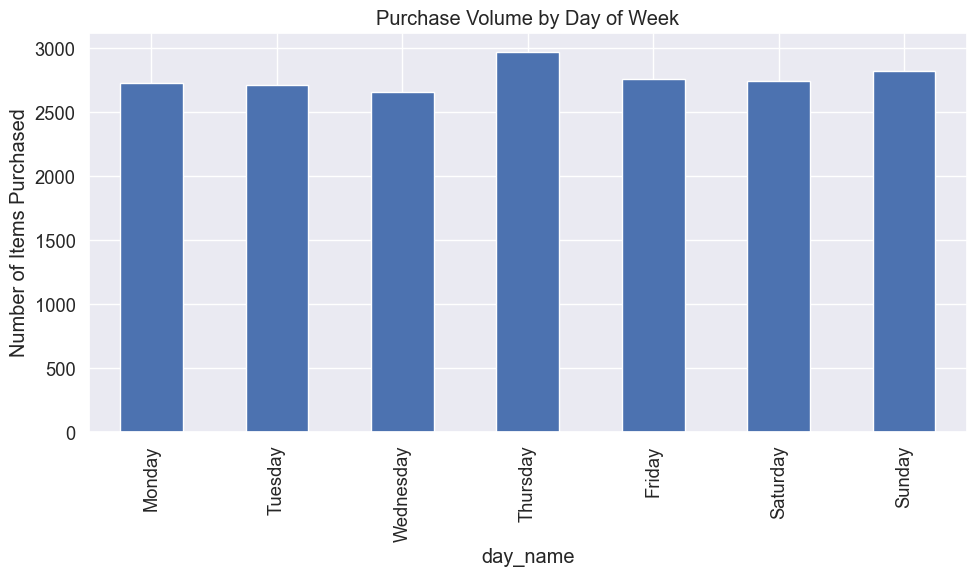

In [9]:
# Purchases by day of week
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
             3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
train_data['day_name'] = train_data['day_of_week'].map(day_names)

plt.figure(figsize=(10, 6))
train_data['day_name'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(kind='bar')
plt.title('Purchase Volume by Day of Week')
plt.ylabel('Number of Items Purchased')
plt.tight_layout()
plt.show()

distribution of purchases across months:

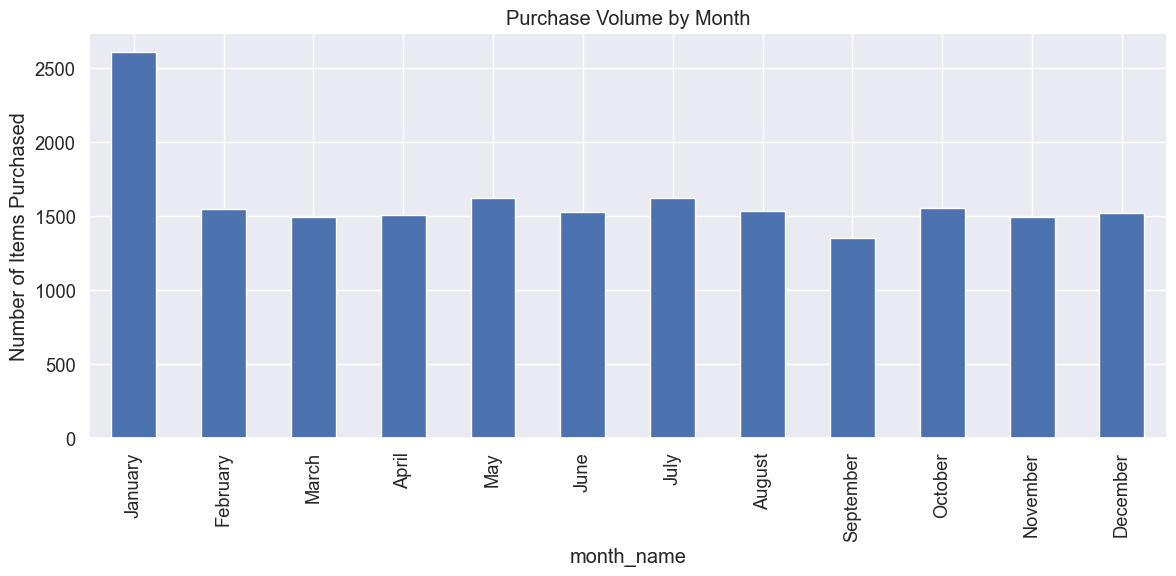

In [10]:
# Purchases by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12, 6))
train_data['month_name'].value_counts().reindex(month_order).plot(kind='bar')
plt.title('Purchase Volume by Month')
plt.ylabel('Number of Items Purchased')
plt.tight_layout()
plt.show()

### 1.2 User Purchase Behavior Analysis

examine how users behave in terms of purchase frequency:

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


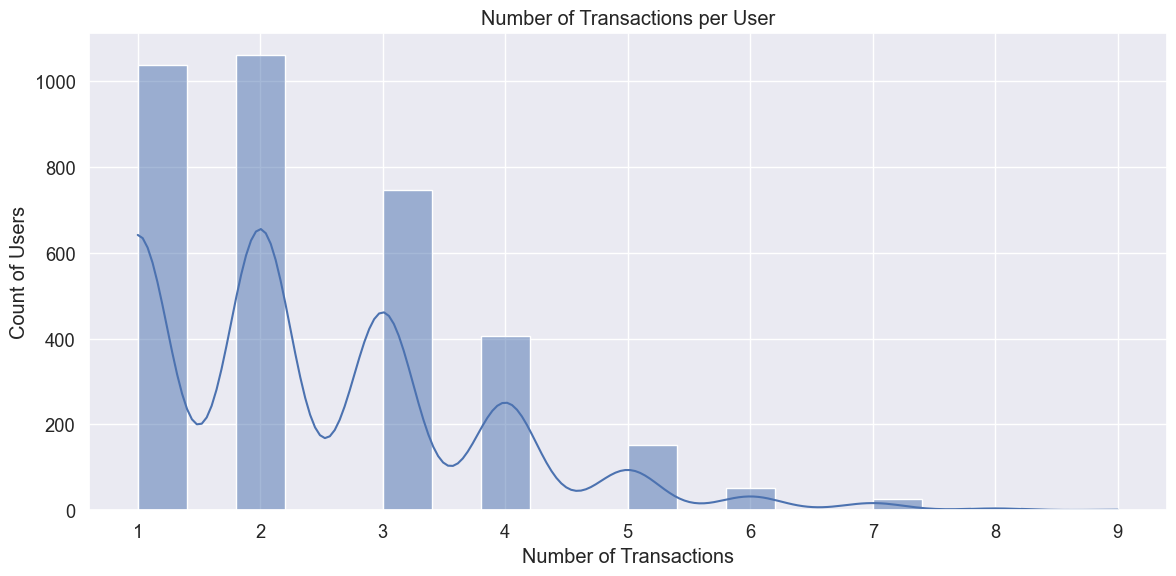

Average transactions per user: 2.39
Median transactions per user: 2.00
Max transactions per user: 9


In [11]:
# Transactions per user
user_transaction_counts = train_data.groupby('User_id')['Date'].nunique()

plt.figure(figsize=(12, 6))
sns.histplot(user_transaction_counts, bins=20, kde=True)
plt.title('Number of Transactions per User')
plt.xlabel('Number of Transactions')
plt.ylabel('Count of Users')
plt.tight_layout()
plt.show()

print(f"Average transactions per user: {user_transaction_counts.mean():.2f}")
print(f"Median transactions per user: {user_transaction_counts.median():.2f}")
print(f"Max transactions per user: {user_transaction_counts.max()}")

 patterns in the purchase time intervals:

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


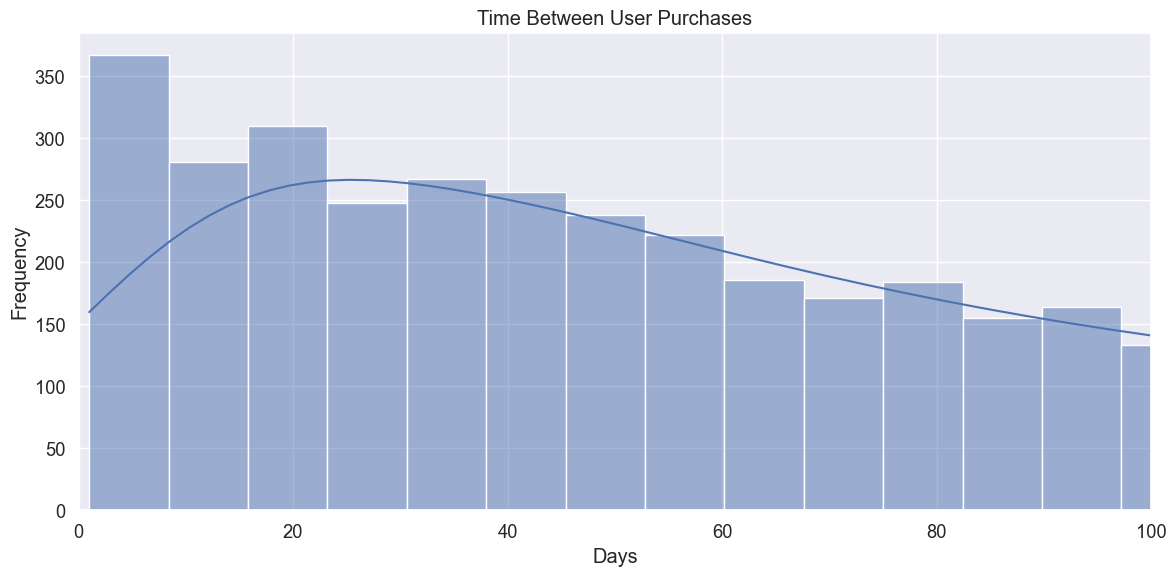

Average days between purchases: 90.42
Median days between purchases: 70.00


In [14]:
# Calculate time between purchases for each user
purchase_intervals = []
for user, group in train_data.groupby('User_id'):
    dates = sorted(group['Date'].unique())
    if len(dates) > 1:  # Only users with multiple purchase dates
        intervals = [(dates[i] - dates[i-1]).days for i in range(1, len(dates))]
        purchase_intervals.extend(intervals)

plt.figure(figsize=(12, 6))
sns.histplot(purchase_intervals, bins=50, kde=True)
plt.title('Time Between User Purchases')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.xlim(0, 100)  # Focus on shorter intervals
plt.tight_layout()
plt.show()

print(f"Average days between purchases: {np.mean(purchase_intervals):.2f}")
print(f"Median days between purchases: {np.median(purchase_intervals):.2f}")


### 1.3 Prepare Transaction Data for Pattern Mining  
Prepare our data in the right format for pattern mining:

In [16]:
def prepare_transactions(data):
    # Group by user and date
    transactions = defaultdict(list)
    for _, row in data.iterrows():
        key = (row['User_id'], row['Date'])
        if pd.notna(row['itemDescription']):  # Skip null items
            transactions[key].append(row['itemDescription'])
    
    # Convert to list of lists
    transaction_list = list(transactions.values())
    
    # Print some statistics
    transaction_sizes = [len(t) for t in transaction_list]
    print(f"Number of transactions: {len(transaction_list)}")
    print(f"Average transaction size: {np.mean(transaction_sizes):.2f} items")
    print(f"Largest transaction: {max(transaction_sizes)} items")
    
    return transaction_list

# Create transaction data
transactions = prepare_transactions(train_data)

Number of transactions: 8361
Average transaction size: 2.32 items
Largest transaction: 9 items


In [17]:
# Show a few sample transactions
print("\nSample transactions:")
for t in transactions[:5]:
    print(t)


Sample transactions:
['cleaner', 'shopping bags']
['sausage', 'bottled water']
['tropical fruit', 'other vegetables']
['whole milk', 'flower (seeds)']
['citrus fruit', 'coffee']


## 2. Implementing the Apriori Algorithm

In [39]:
class AprioriMiner:
    def __init__(self, min_support=0.005):
        self.min_support = min_support
        self.transactions = None
        self.num_transactions = 0
        self.frequent_itemsets = {}
        self.item_support = {}
    
    def fit(self, transactions):
        """
        Find frequent itemsets using the Apriori algorithm.
        
        Parameters:
        -----------
        transactions : list of lists
            List of transactions, where each transaction is a list of items
        
        Returns:
        --------
        dict
            Dictionary with keys as itemset size and values as list of (itemset, support) tuples
        """
        self.transactions = transactions
        self.num_transactions = len(transactions)
        
        # Step 1: Count support for each individual item
        item_counts = defaultdict(int)
        for transaction in transactions:
            for item in set(transaction):  # Use set to count each item once per transaction
                item_counts[item] += 1
        
        # Filter by minimum support
        min_count = self.min_support * self.num_transactions
        self.item_support = {item: count/self.num_transactions for item, count in item_counts.items() 
                           if count >= min_count}
        
        # Initialize L1 (frequent 1-itemsets)
        L1 = [frozenset([item]) for item in self.item_support.keys()]
        current_L = L1
        k = 1
        
        # Store all frequent itemsets
        self.frequent_itemsets = {
            k: [(itemset, self.item_support[list(itemset)[0]]) for itemset in L1]
        }
        
        # Main Apriori loop
        while current_L:
            k += 1
            # Generate candidate k-itemsets
            Ck = self._generate_candidates(current_L, k)
            
            if not Ck:
                break  # No candidates generated
                
            # Count support for candidates
            itemset_counts = defaultdict(int)
            for transaction in transactions:
                transaction_set = set(transaction)
                for candidate in Ck:
                    if candidate.issubset(transaction_set):
                        itemset_counts[candidate] += 1
            
            # Filter by minimum support
            Lk = [itemset for itemset, count in itemset_counts.items() 
                 if count >= min_count]
            
            # Store k-itemsets with their support
            if Lk:
                self.frequent_itemsets[k] = [(itemset, itemset_counts[itemset]/self.num_transactions) 
                                           for itemset in Lk]
            
            # Prepare for next iteration
            current_L = Lk
        
        return self.frequent_itemsets
    
    def _generate_candidates(self, prev_itemsets, k):
        """Generate candidate k-itemsets from (k-1)-itemsets"""
        candidates = set()
        
        # For more efficient processing, convert to list of sets
        prev_sets = [set(itemset) for itemset in prev_itemsets]
        
        # For each pair of (k-1)-itemsets
        for i in range(len(prev_sets)):
            for j in range(i+1, len(prev_sets)):
                # Join step
                union = prev_sets[i].union(prev_sets[j])
                if len(union) == k:
                    # Check if all (k-1) subsets are frequent
                    is_valid = True
                    for item in union:
                        subset = union - {item}
                        if frozenset(subset) not in [frozenset(s) for s in prev_itemsets]:
                            is_valid = False
                            break
                    
                    if is_valid:
                        candidates.add(frozenset(union))
        
        return list(candidates)
    
    def generate_rules(self, min_confidence=0.5):
        """
        Generate association rules from frequent itemsets.
        
        Parameters:
        -----------
        min_confidence : float, default=0.5
            Minimum confidence threshold for rules
        
        Returns:
        --------
        list
            List of (antecedent, consequent, support, confidence, lift) tuples
        """
        rules = []
        
        # Helper function to find support for an itemset
        def find_support(itemset):
            for k in self.frequent_itemsets:
                for (candidate, support) in self.frequent_itemsets[k]:
                    if candidate == itemset:
                        return support
            return 0  # Should not happen for frequent itemsets
        
        # For each k-itemset where k >= 2
        for k in self.frequent_itemsets:
            if k < 2:
                continue
            print('hi') 
            for itemset, itemset_support in self.frequent_itemsets[k]:
                
                # Generate all non-empty proper subsets
                subsets = []
                for i in range(1, k):
                    subsets.extend([frozenset(subset) for subset in combinations(itemset, i)])
                
                # For each subset, create a rule
                for antecedent in subsets:
                    consequent = itemset - antecedent
                    
                    # Skip empty consequents
                    if not consequent:
                        continue
                    
                    # Calculate confidence
                    antecedent_support = find_support(antecedent)
                    confidence = itemset_support / antecedent_support
                    
                    if confidence >= min_confidence:
                        # Calculate lift
                        consequent_support = find_support(consequent)
                        lift = confidence / consequent_support
                        
                        rules.append({
                            'antecedent': list(antecedent),
                            'consequent': list(consequent),
                            'support': itemset_support,
                            'confidence': confidence,
                            'lift': lift
                        })
        
        return rules

In [36]:
# Run the Apriori algorithm on our transaction data
min_support = 0.005  # 0.5%
miner = AprioriMiner(min_support=min_support)
frequent_itemsets = miner.fit(transactions)

In [37]:
# Print the number of frequent itemsets by size
for k in sorted(frequent_itemsets.keys()):
    print(f"Number of frequent {k}-itemsets: {len(frequent_itemsets[k])}")

Number of frequent 1-itemsets: 91
Number of frequent 2-itemsets: 10


In [38]:
# Display top frequent itemsets by support
all_itemsets = []
for k in frequent_itemsets:
    all_itemsets.extend([(list(itemset), support, k) for itemset, support in frequent_itemsets[k]])

print("\nTop 20 frequent itemsets by support:")
for i, (itemset, support, size) in enumerate(sorted(all_itemsets, key=lambda x: x[1], reverse=True)[:20]):
    print(f"{i+1}. {itemset} (size: {size}, support: {support:.4f})")


Top 20 frequent itemsets by support:
1. ['whole milk'] (size: 1, support: 0.1305)
2. ['other vegetables'] (size: 1, support: 0.1067)
3. ['rolls/buns'] (size: 1, support: 0.1019)
4. ['soda'] (size: 1, support: 0.0946)
5. ['yogurt'] (size: 1, support: 0.0786)
6. ['bottled water'] (size: 1, support: 0.0608)
7. ['root vegetables'] (size: 1, support: 0.0604)
8. ['shopping bags'] (size: 1, support: 0.0527)
9. ['pastry'] (size: 1, support: 0.0496)
10. ['tropical fruit'] (size: 1, support: 0.0488)
11. ['whipped/sour cream'] (size: 1, support: 0.0444)
12. ['newspapers'] (size: 1, support: 0.0414)
13. ['bottled beer'] (size: 1, support: 0.0405)
14. ['brown bread'] (size: 1, support: 0.0402)
15. ['domestic eggs'] (size: 1, support: 0.0397)
16. ['pip fruit'] (size: 1, support: 0.0376)
17. ['fruit/vegetable juice'] (size: 1, support: 0.0367)
18. ['margarine'] (size: 1, support: 0.0354)
19. ['citrus fruit'] (size: 1, support: 0.0346)
20. ['canned beer'] (size: 1, support: 0.0342)


generate and analyze association rules:

In [23]:
# Generate association rules
min_confidence = 0.3  # 30%
rules = miner.generate_rules(min_confidence=min_confidence)

print(f"Generated {len(rules)} association rules with min confidence {min_confidence}")

# Sort rules by lift
sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)

# Display top rules by lift
print("\nTop 20 association rules by lift:")
for i, rule in enumerate(sorted_rules[:20]):
    print(f"{i+1}. {rule['antecedent']} => {rule['consequent']} "
          f"(support: {rule['support']:.4f}, confidence: {rule['confidence']:.4f}, lift: {rule['lift']:.4f})")

Generated 0 association rules with min confidence 0.3

Top 20 association rules by lift:


In [40]:
miner.generate_rules(min_confidence=min_confidence)

hi
hi
hi
hi
hi
hi
hi
hi
hi
hi


[]

In [30]:
miner.frequent_itemsets

{1: [(frozenset({'shopping bags'}), 0.0527448869752422),
  (frozenset({'sausage'}), 0.02571462743690946),
  (frozenset({'bottled water'}), 0.06075828250209305),
  (frozenset({'other vegetables'}), 0.10668580313359646),
  (frozenset({'tropical fruit'}), 0.048797990670972374),
  (frozenset({'flower (seeds)'}), 0.005621337160626719),
  (frozenset({'whole milk'}), 0.1304867838775266),
  (frozenset({'coffee'}), 0.03061834708766894),
  (frozenset({'citrus fruit'}), 0.03456524339193876),
  (frozenset({'dishes'}), 0.008850615955029303),
  (frozenset({'onions'}), 0.015787585217079295),
  (frozenset({'whipped/sour cream'}), 0.04437268269345772),
  (frozenset({'yogurt'}), 0.07857911733046287),
  (frozenset({'berries'}), 0.016265996890324125),
  (frozenset({'hamburger meat'}), 0.017222820236813777),
  (frozenset({'frozen potato products'}), 0.005382131324004306),
  (frozenset({'bottled beer'}), 0.040545389307499104),
  (frozenset({'domestic eggs'}), 0.03970816887932065),
  (frozenset({'butter'}), 

In [ ]:
# Visualize rule metrics
rule_df = pd.DataFrame(sorted_rules)

plt.figure(figsize=(12, 8))
plt.scatter(rule_df['support'], rule_df['confidence'], 
            s=rule_df['lift']*50, alpha=0.5)
plt.title('Association Rules: Support vs Confidence (size represents lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True)
plt.tight_layout()
plt.show()